In [33]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

from google.colab import files, drive

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Plate parameters
size = 2.0  # Length of the plate
t_max = 5.0  # Maximum time
alpha = 0.01  # Thermal diffusivity (known value)

# Hyperparameters
layers = [3, 64, 64, 64, 1]
lr = 0.001
batch_size = 32
epochs = 50

Using device: cuda


In [ ]:
!wget -O gaussian.csv https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/gaussian.csv
!wget -O dual_gaussian_4.csv https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/dual_gaussian_4.csv
!wget -O dual_gaussian_8.csv https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/dual_gaussian_8.csv
!wget -O square_step.csv https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/square_step.csv
!wget -O dual_gaussian_8_noisy.csv https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/dual_gaussian_8_noisy.csv

class CSVDataset(Dataset):
    def __init__(self, csv_file):
        self.data = pd.read_csv(csv_file).values.astype('float32')
        self.X = torch.tensor(self.data[:, 1:4])
        self.y = torch.tensor(self.data[:, 4:])

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# dataset = CSVDataset('gaussian.csv')
# dataset = CSVDataset('dual_gaussian_4.csv')
# dataset = CSVDataset('dual_gaussian_8.csv')
# dataset = CSVDataset('square_step.csv')
dataset = CSVDataset('dual_gaussian_8_noisy.csv')

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# next(iter(dataloader))  # Check the first batch

--2026-04-05 05:14:59--  https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/gaussian.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1070974 (1.0M) [text/plain]
Saving to: ‘gaussian.csv’

gaussian.csv        100%[===================>]   1.02M  --.-KB/s    in 0.03s   

2026-04-05 05:14:59 (32.1 MB/s) - ‘gaussian.csv’ saved [1070974/1070974]

--2026-04-05 05:14:59--  https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/dual_gaussian_4.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK

In [36]:
class HeatPINN(nn.Module):
    """
    A simple feedforward neural network
    """
    def __init__(self, layers):
        """
        Parameters
        ----------
        layers : list
            A list of integers specifying the number of neurons in each layer, including input and output layers.
        """
        super(HeatPINN, self).__init__()

        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                # self.layers.append(nn.Tanh())
                self.layers.append(nn.SiLU())

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


In [37]:
def sample_points(num_points, size, t_max):
    """
    Sample points uniformly from the domain [-L/2, L/2] x [-L/2, L/2] x [0, t_max]

    Parameters
    ----------
    num_points : int
        The number of points to sample.
    size : float
        The size of the spatial domain (length of the plate).
    t_max : float
        The maximum time to sample from.

    Returns
    -------
    torch.Tensor
        A tensor of shape (num_points, 3) containing the sampled points.
    """
    x = torch.rand(num_points, 1) * size - size / 2  # Sample x in [-L/2, L/2]
    y = torch.rand(num_points, 1) * size - size / 2  # Sample y in [-L/2, L/2]
    t = torch.rand(num_points, 1) * t_max  # Sample t in [0, t_max]

    x.requires_grad = True
    y.requires_grad = True
    t.requires_grad = True

    return torch.cat([x, y, t], dim=1)


def sample_boundary_points(num_points, size, t_max):
    """
    Uniformly samples points from the boundary of the plate
    over the full time interval.

    Parameters
    ----------
    num_points : int
        The number of points to sample.
    size : float
        The size of the spatial domain (length of the plate).
    t_max : float
        The maximum time to sample from.

    Returns
    -------
    torch.Tensor
        A tensor of shape (num_points, 3) containing the sampled boundary points.
    """
    points_per_edge = num_points // 4
    # left edge (x = -L/2)
    x_left = torch.full((points_per_edge, 1), -size / 2)
    y_left = torch.rand(points_per_edge, 1) * size - size / 2
    t_left = torch.rand(points_per_edge, 1) * t_max
    left_edge = torch.cat([x_left, y_left, t_left], dim=1)
    
    # right edge (x = L/2)
    x_right = torch.full((points_per_edge, 1), size / 2)
    y_right = torch.rand(points_per_edge, 1) * size - size / 2
    t_right = torch.rand(points_per_edge, 1) * t_max
    right_edge = torch.cat([x_right, y_right, t_right], dim=1)
    
    # top edge (y = -L/2)
    x_top = torch.rand(points_per_edge, 1) * size - size / 2
    y_top = torch.full((points_per_edge, 1), -size / 2)
    t_top = torch.rand(points_per_edge, 1) * t_max
    top_edge = torch.cat([x_top, y_top, t_top], dim=1)
    
    # bottom edge (y = L/2)
    x_bottom = torch.rand(points_per_edge, 1) * size - size / 2
    y_bottom = torch.full((points_per_edge, 1), size / 2)
    t_bottom = torch.rand(points_per_edge, 1) * t_max
    bottom_edge = torch.cat([x_bottom, y_bottom, t_bottom], dim=1)

    # Concatenate all boundary points
    boundary_points = torch.cat([left_edge, right_edge, top_edge, bottom_edge], dim=0)
    
    # requires_grad not needed because no dirivatives will be used
    return boundary_points

In [38]:
def data_loss(model, x_batch, y_batch):
    """
    Supervised loss on sampled dataset points.

    Parameters
    ----------
    model : nn.Module
        The PINN model.
    x_batch : torch.Tensor
        A batch of input points (x, y, t).
    y_batch : torch.Tensor
        A batch of corresponding temperature values.
    
    Returns
    -------
    torch.Tensor
        The mean squared error loss between the model predictions and the true values.
    """
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    pred = model(x_batch)
    return torch.mean((pred - y_batch) ** 2)


def physics_loss(model, points, alpha):
    """
    Physics loss enforcing the heat equation at sampled points.

    Parameters
    ----------
    model : nn.Module
        The PINN model.
    points : torch.Tensor
        A batch of input points (x, y, t) where the physics loss is evaluated.
    alpha : float
        The thermal diffusivity (known value).
    
    Returns
    -------
    torch.Tensor
        The mean squared error loss enforcing the heat equation at the given points.
    """
    points = points.to(device)
    pred = model(points)

    # Compute gradients for PDE residual
    grad = torch.autograd.grad(pred, points, grad_outputs=torch.ones_like(pred), create_graph=True)[0]
    u_t = grad[:, 2:3]  # Time derivative
    u_x = grad[:, 0:1]  # Spatial derivative in x
    u_y = grad[:, 1:2]  # Spatial derivative in y

    u_xx = torch.autograd.grad(u_x, points, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = torch.autograd.grad(u_y, points, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

    # Heat equation residual: u_t - alpha * (u_xx + u_yy) = 0
    residual = u_t - alpha * (u_xx + u_yy)
    
    return torch.mean(residual ** 2)


def boundary_loss(model, boundary_points):
    """
    Boundary loss enforcing the boundary conditions at sampled boundary points.

    Parameters
    ----------
    model : nn.Module
        The PINN model.
    boundary_points : torch.Tensor
        A batch of input points (x, y, t) on the boundary where the boundary loss is evaluated.
    
    Returns
    -------
    torch.Tensor
        The mean squared error loss enforcing the boundary conditions at the given points.
    """
    boundary_points = boundary_points.to(device)
    pred = model(boundary_points)

    # For this example, we assume Dirichlet boundary conditions with u = 0 on the boundary
    return torch.mean(pred ** 2)

In [39]:
def train(model, dataloader, optimizer, scheduler, epochs, adaptive_loss_weights):
    import time
    model.train()
    for epoch in range(epochs):
        epoch_start = time.time()
        total_loss = 0.0
        total_data_loss = 0.0
        total_physics_loss = 0.0
        total_boundary_loss = 0.0

        for x_batch, y_batch in dataloader:
            optimizer.zero_grad()

            # Sample points for physics and boundary losses
            physics_points = sample_points(batch_size, size, t_max)
            boundary_points = sample_boundary_points(batch_size, size, t_max)

            # Compute losses
            loss_data = data_loss(model, x_batch, y_batch)
            loss_physics = physics_loss(model, physics_points, alpha)
            loss_boundary = boundary_loss(model, boundary_points)

            # Calculate adaptive weights
            lambda_data = torch.exp(-adaptive_loss_weights[0])
            lambda_phys = torch.exp(-adaptive_loss_weights[1])
            lambda_bc = torch.exp(-adaptive_loss_weights[2])
            
            # Total loss with weighting
            loss = (
                lambda_data * loss_data + adaptive_loss_weights[0] +
                lambda_phys * loss_physics + adaptive_loss_weights[1] +
                lambda_bc * loss_boundary + adaptive_loss_weights[2]
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss_data.item() + loss_physics.item() + loss_boundary.item() # unweighted for logging
            total_data_loss += loss_data.item()
            total_physics_loss += loss_physics.item()
            total_boundary_loss += loss_boundary.item()

        # Decay learning rate at end of epoch
        if scheduler is not None:
            scheduler.step()

        epoch_time = time.time() - epoch_start
        avg_loss = total_loss / len(dataloader)
        avg_data_loss = total_data_loss / len(dataloader)
        avg_physics_loss = total_physics_loss / len(dataloader)
        avg_boundary_loss = total_boundary_loss / len(dataloader)

        print(f'Epoch {epoch+1:03d}/{epochs}, Loss (unweighted): {avg_loss:.6f}, Data: {avg_data_loss:.6f}, Physics: {avg_physics_loss:.6f}, Boundary: {avg_boundary_loss:.6f}, Time: {epoch_time:.2f}s')

In [40]:
model = HeatPINN(layers).to(device)

adaptive_loss_weights = nn.Parameter(torch.zeros(3, device=device))
optimizer = torch.optim.Adam([
    {'params': model.parameters(), 'lr': lr},
    {'params': adaptive_loss_weights, 'lr': lr * 1.5}
], lr=lr)

# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.98)
scheduler = None

train(model, dataloader, optimizer, scheduler, epochs, adaptive_loss_weights)

Epoch 001/50, Loss (unweighted): 0.071356, Data: 0.043478, Physics: 0.000714, Boundary: 0.027165, Time: 5.26s
Epoch 002/50, Loss (unweighted): 0.015182, Data: 0.010148, Physics: 0.000296, Boundary: 0.004738, Time: 4.63s
Epoch 003/50, Loss (unweighted): 0.008188, Data: 0.005867, Physics: 0.000416, Boundary: 0.001905, Time: 4.66s
Epoch 004/50, Loss (unweighted): 0.003585, Data: 0.001314, Physics: 0.000663, Boundary: 0.001608, Time: 5.19s
Epoch 005/50, Loss (unweighted): 0.001700, Data: 0.000287, Physics: 0.000530, Boundary: 0.000883, Time: 4.71s
Epoch 006/50, Loss (unweighted): 0.001097, Data: 0.000164, Physics: 0.000411, Boundary: 0.000522, Time: 5.24s
Epoch 007/50, Loss (unweighted): 0.000831, Data: 0.000127, Physics: 0.000334, Boundary: 0.000370, Time: 4.66s
Epoch 008/50, Loss (unweighted): 0.000627, Data: 0.000108, Physics: 0.000262, Boundary: 0.000257, Time: 4.68s
Epoch 009/50, Loss (unweighted): 0.000501, Data: 0.000093, Physics: 0.000210, Boundary: 0.000198, Time: 5.24s
Epoch 010/

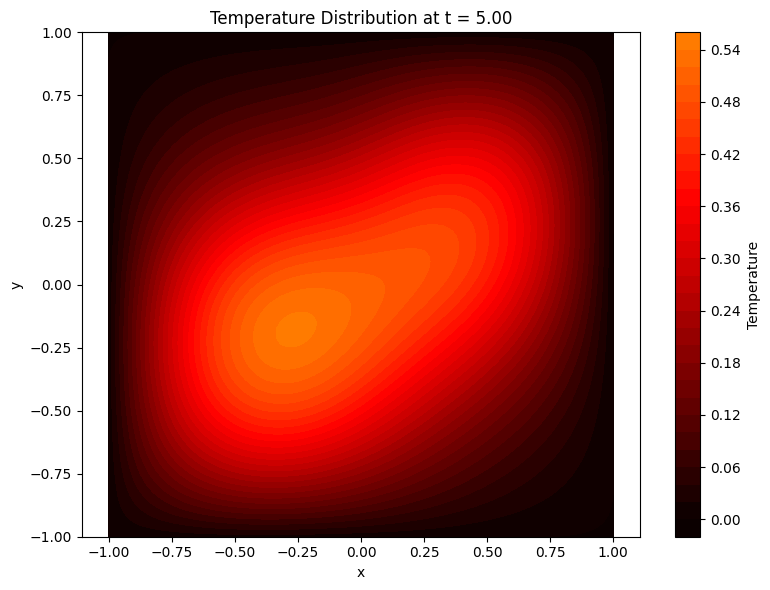

In [46]:
def plot_heatmap(model, t, size=2.0, resolution=100):
    """
    Plot a heatmap of the temperature distribution at a given time.
    
    Parameters
    ----------
    model : nn.Module
        The trained PINN model.
    t : float
        The time at which to plot the temperature distribution.
    size : float
        The size of the spatial domain (length of the plate).
    resolution : int
        The number of points in each spatial dimension for the grid.
    """
    model.eval()
    
    # Create a grid of (x, y) points
    x = torch.linspace(-size/2, size/2, resolution)
    y = torch.linspace(-size/2, size/2, resolution)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    
    # Flatten and create input tensor with constant time
    x_flat = X.flatten().unsqueeze(1)
    y_flat = Y.flatten().unsqueeze(1)
    t_tensor = torch.full_like(x_flat, t)
    
    points = torch.cat([x_flat, y_flat, t_tensor], dim=1).to(device)
    
    # Get predictions
    with torch.no_grad():
        u = model(points)
    
    # Reshape to grid
    U = u.reshape(resolution, resolution).cpu().numpy()
    
    # Plot
    plt.figure(figsize=(8, 6), dpi=100)
    plt.contourf(X.numpy(), Y.numpy(), U, levels=30, cmap='hot', vmin=0, vmax=1)
    plt.colorbar(label='Temperature')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Temperature Distribution at t = {t:.2f}')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    model.train()

plot_heatmap(model, t=5, size=size, resolution=100)

In [42]:
# drive.mount('/content/drive')
# timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
# torch.save(model.state_dict(), f'/content/drive/My Drive/Heat PINN weights/heat_pinn_model_{timestamp}.pth')